# 🎬 Lumiere — Neural Collaborative Filtering (NCF)

Notebook ini membangun sistem rekomendasi film berbasis **Neural Collaborative Filtering (NeuMF)**  
menggunakan dataset **MovieLens 1M** (~1 juta rating dari 6.040 user terhadap 3.706 film).

### Arsitektur Model
Model menggabungkan dua jalur komputasi:
- **GMF (Generalized Matrix Factorization)** — menangkap hubungan *linear* antara user dan film
- **MLP (Multi-Layer Perceptron)** — menangkap hubungan *non-linear* yang kompleks

### Alur Notebook
1. Preprocessing & Encoding
2. Split Data & Normalisasi
3. Pembangunan Arsitektur NCF
4. Training & Evaluasi
5. Visualisasi
6. Export Model untuk Deployment (GCP)

## 1. Import Library

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Multiply, Concatenate, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia        : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU tersedia        : []


## 2. Load & Preprocessing Data

Load dataset `ratings.dat` dari MovieLens 1M, lakukan pembersihan, lalu encode UserID dan MovieID  
menjadi indeks integer berurutan (0, 1, 2, ...) agar bisa digunakan sebagai input Embedding layer.

In [ ]:
# ── Load raw data ──────────────────────────────────────────────────────────────
PATH_RATINGS = "ratings.dat"
columns = ['UserID', 'MovieID', 'Rating', 'Timestamp']

df = pd.read_csv(PATH_RATINGS, sep='::', engine='python', names=columns, encoding='latin-1')
print(f"Total data awal        : {df.shape[0]:,} baris")

# ── Bersihkan duplikat & NaN ───────────────────────────────────────────────────
df = df.dropna().drop_duplicates(subset=['UserID', 'MovieID'], keep='last')
print(f"Total setelah bersih   : {df.shape[0]:,} baris")

# ── Encode ID → indeks integer berurutan ──────────────────────────────────────
user_to_index  = {uid: idx for idx, uid in enumerate(df['UserID'].unique())}
movie_to_index = {mid: idx for idx, mid in enumerate(df['MovieID'].unique())}

# Simpan mapping untuk kebutuhan inference / deployment
index_to_user  = {v: k for k, v in user_to_index.items()}
index_to_movie = {v: k for k, v in movie_to_index.items()}

df['user_idx']  = df['UserID'].map(user_to_index)
df['movie_idx'] = df['MovieID'].map(movie_to_index)

print(f"Jumlah user unik       : {len(user_to_index):,}")
print(f"Jumlah film unik       : {len(movie_to_index):,}")

Total data awal        : 1,000,209 baris
Total setelah bersih   : 1,000,209 baris
Jumlah user unik       : 6,040
Jumlah film unik       : 3,706


## 3. Split Data & Simpan ke CSV

Bagi data 80% training / 20% testing secara random dengan `random_state=42` untuk reprodusibilitas.  
CSV disimpan agar preprocessing tidak perlu diulang setiap kali training.

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.to_csv("train_ratings.csv", index=False)
test_df.to_csv("test_ratings.csv", index=False)

print(f"Training set : {train_df.shape[0]:,} baris  → train_ratings.csv")
print(f"Testing set  : {test_df.shape[0]:,} baris  → test_ratings.csv")

Training set : 800,167 baris  → train_ratings.csv
Testing set  : 200,042 baris  → test_ratings.csv


## 4. Load Data & Persiapan Input Model

Load kembali CSV, pastikan tipe data bersih, lalu siapkan array input `X` dan target `y`.  
Rating dinormalisasi dengan **Min-Max scaling** ke rentang [0, 1] agar kompatibel dengan output layer.

In [ ]:
# ── Load CSV ───────────────────────────────────────────────────────────────────
train_df = pd.read_csv("train_ratings.csv")
test_df  = pd.read_csv("test_ratings.csv")

print(f"Training set : {train_df.shape[0]:,} baris")
print(f"Testing set  : {test_df.shape[0]:,} baris")

# ── Bersihkan & pastikan tipe data ────────────────────────────────────────────
for df_part in [train_df, test_df]:
    df_part.dropna(subset=['user_idx', 'movie_idx', 'Rating'], inplace=True)
    df_part['user_idx']  = df_part['user_idx'].astype(np.int32)
    df_part['movie_idx'] = df_part['movie_idx'].astype(np.int32)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ── Dimensi embedding ─────────────────────────────────────────────────────────
num_users  = int(max(train_df['user_idx'].max(), test_df['user_idx'].max()) + 1)
num_movies = int(max(train_df['movie_idx'].max(), test_df['movie_idx'].max()) + 1)

print(f"\nDimensi embedding:")
print(f"  num_users  = {num_users}")
print(f"  num_movies = {num_movies}")

# ── Input features (X) ────────────────────────────────────────────────────────
X_train = [train_df['user_idx'].values, train_df['movie_idx'].values]
X_test  = [test_df['user_idx'].values,  test_df['movie_idx'].values]

# ── Target (y) — Min-Max normalisasi ke [0, 1] ────────────────────────────────
RATING_MIN = 1.0
RATING_MAX = 5.0

y_train = (train_df['Rating'].values - RATING_MIN) / (RATING_MAX - RATING_MIN)
y_test  = (test_df['Rating'].values  - RATING_MIN) / (RATING_MAX - RATING_MIN)

print(f"\nRentang y_train : [{y_train.min():.1f}, {y_train.max():.1f}]")
print(f"Sinkronisasi X–y: {len(X_train[0]) == len(y_train)}  ✓")

Training set : 800,167 baris
Testing set  : 200,042 baris

Dimensi embedding:
  num_users  = 6040
  num_movies = 3706

Rentang y_train : [0.0, 1.0]
Sinkronisasi X–y: True  ✓


## 5. Arsitektur Model NCF (NeuMF)

Model menggabungkan **GMF** dan **MLP** dalam satu jaringan:

| Komponen | Detail |
|---|---|
| Embedding size | 32 per path (GMF & MLP) |
| GMF path | Element-wise product, tanpa Dropout |
| MLP path | Concatenate → Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.2) |
| Output | Dense(1, activation='sigmoid') → prediksi rating [0, 1] |
| Loss | MSE | Optimizer | Adam (lr=0.001) |

In [ ]:
# ── Hyperparameter ────────────────────────────────────────────────────────────
EMBEDDING_SIZE = 32
L2_REG         = 1e-4

# ── Input layer ───────────────────────────────────────────────────────────────
user_input  = Input(shape=(1,), name='user_input')
movie_input = Input(shape=(1,), name='movie_input')

# ── GMF path ──────────────────────────────────────────────────────────────────
user_embed_gmf  = Embedding(num_users,  EMBEDDING_SIZE, embeddings_regularizer=l2(L2_REG), name='gmf_user_embedding')(user_input)
movie_embed_gmf = Embedding(num_movies, EMBEDDING_SIZE, embeddings_regularizer=l2(L2_REG), name='gmf_movie_embedding')(movie_input)
gmf_vector = Multiply(name='gmf_product')([Flatten()(user_embed_gmf), Flatten()(movie_embed_gmf)])

# ── MLP path ──────────────────────────────────────────────────────────────────
user_embed_mlp  = Embedding(num_users,  EMBEDDING_SIZE, embeddings_regularizer=l2(L2_REG), name='mlp_user_embedding')(user_input)
movie_embed_mlp = Embedding(num_movies, EMBEDDING_SIZE, embeddings_regularizer=l2(L2_REG), name='mlp_movie_embedding')(movie_input)
mlp_vector = Concatenate(name='mlp_concat')([Flatten()(user_embed_mlp), Flatten()(movie_embed_mlp)])

mlp_layer = Dense(64, activation='relu', name='mlp_dense_1')(mlp_vector)
mlp_layer = Dropout(0.3, name='mlp_dropout_1')(mlp_layer)
mlp_layer = Dense(32, activation='relu', name='mlp_dense_2')(mlp_layer)
mlp_layer = Dropout(0.2, name='mlp_dropout_2')(mlp_layer)

# ── Fusion & Output ───────────────────────────────────────────────────────────
predict_vector = Concatenate(name='fusion')([gmf_vector, mlp_layer])
output_layer   = Dense(1, activation='sigmoid', name='output')(predict_vector)

model = Model(inputs=[user_input, movie_input], outputs=output_layer, name='NeuMF')

# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "NeuMF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_user_embedding  │ (None, 1, 32)     │    193,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_movie_embedding │ (None, 1, 32)     │    118,592 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ mlp_user_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ mlp_movie_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_concat          │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 64)        │      4,160 │ mlp_concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_user_embedding  │ (None, 1, 32)     │    193,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_movie_embedding │ (None, 1, 32)     │    118,592 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_1       │ (None, 64)        │          0 │ mlp_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ gmf_user_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ gmf_movie_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 32)        │      2,080 │ mlp_dropout_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_product         │ (None, 32)        │          0 │ flatten[0][0],    │
│ (Multiply)          │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_2       │ (None, 32)        │          0 │ mlp_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 64)        │          0 │ gmf_product[0][0… │
│ (Concatenate)       │                   │            │ mlp_dropout_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ fusion[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 630,049 (2.40 MB)

 Trainable params: 630,049 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Callbacks

- **EarlyStopping** — hentikan training jika `val_loss` tidak membaik selama 10 epoch, lalu restore bobot terbaik
- **ReduceLROnPlateau** — potong learning rate 50% jika `val_loss` tidak membaik selama 4 epoch

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    min_delta=1e-4,
    verbose=1
)

print("Callbacks siap.")

Callbacks siap.


## 7. Training

Training dijalankan hingga maksimal 100 epoch dengan `batch_size=512`.  
EarlyStopping akan menghentikan training secara otomatis saat konvergen.

In [ ]:
history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=512,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.0616 - rmse: 0.2379 - val_loss: 0.0581 - val_rmse: 0.2317 - learning_rate: 0.0010
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0573 - rmse: 0.2303 - val_loss: 0.0565 - val_rmse: 0.2288 - learning_rate: 0.0010
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0562 - rmse: 0.2280 - val_loss: 0.0559 - val_rmse: 0.2272 - learning_rate: 0.0010
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0555 - rmse: 0.2265 - val_loss: 0.0552 - val_rmse: 0.2259 - learning_rate: 0.0010
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0550 - rmse: 0.2255 - val_loss: 0.0549 - val_rmse: 0.2253 - learning_rate: 0.0010
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0547 - rmse: 0.2250 - val_loss: 0.0544 - val_rmse: 0.2245 - learning_rate: 0.0010
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0544 - rmse: 0.2245 - val_loss: 0.0544 

## 8. Evaluasi & Visualisasi

Evaluasi model pada test set dan tampilkan grafik Loss / RMSE per epoch.

In [ ]:
# ── Evaluasi akhir ────────────────────────────────────────────────────────────
test_loss, test_rmse = model.evaluate(X_test, y_test, verbose=0)
test_rmse_original   = test_rmse * (RATING_MAX - RATING_MIN)  # konversi ke skala 1-5

print(f"Test Loss (MSE)        : {test_loss:.4f}")
print(f"Test RMSE (normalized) : {test_rmse:.4f}")
print(f"Test RMSE (skala 1-5)  : {test_rmse_original:.4f}")

Test Loss (MSE)        : 0.0498
Test RMSE (normalized) : 0.2194
Test RMSE (skala 1-5)  : 0.8776


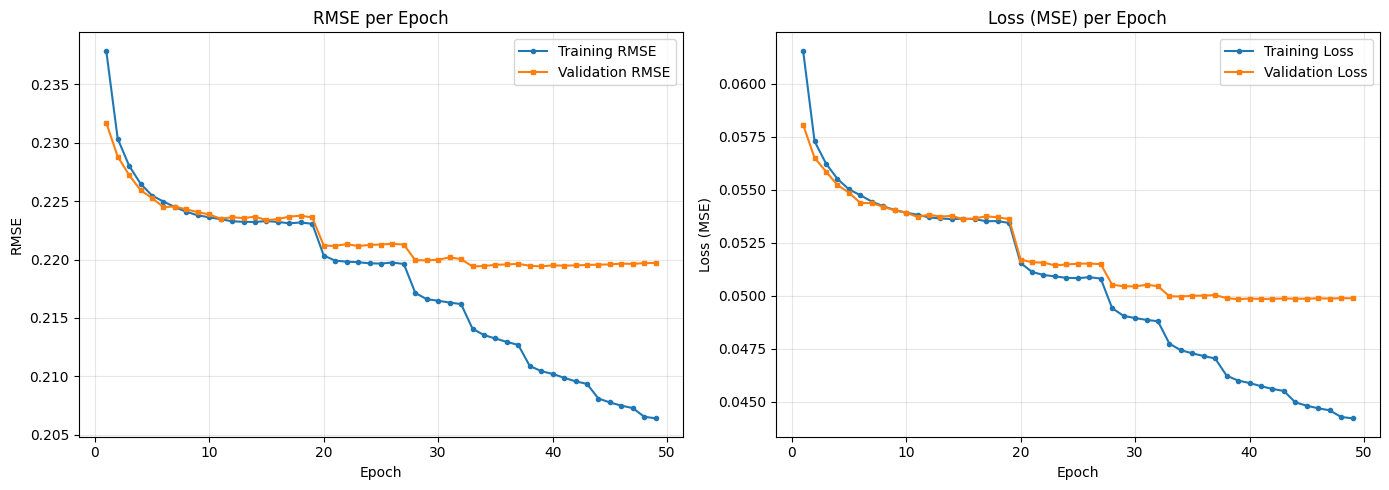

Grafik disimpan → training_history.png


In [ ]:
# ── Grafik Loss & RMSE ────────────────────────────────────────────────────────
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].plot(epochs_range, history.history['rmse'],     label='Training RMSE', marker='o', markersize=3)
axes[0].plot(epochs_range, history.history['val_rmse'], label='Validation RMSE', marker='s', markersize=3)
axes[0].set_title('RMSE per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history['loss'],     label='Training Loss', marker='o', markersize=3)
axes[1].plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='s', markersize=3)
axes[1].set_title('Loss (MSE) per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan → training_history.png")

## 9. Fungsi Inference

Fungsi `get_top_k_recommendations()` menerima `UserID` asli (bukan indeks)  
dan mengembalikan daftar film rekomendasi beserta predicted rating-nya.

In [ ]:
# ── Load metadata film (untuk tampilkan judul) ────────────────────────────────
PATH_MOVIES = "movies.dat"
movies_df = pd.read_csv(
    PATH_MOVIES, sep='::', engine='python',
    names=['MovieID', 'Title', 'Genres'], encoding='latin-1'
)
movie_id_to_title = dict(zip(movies_df['MovieID'], movies_df['Title']))
print(f"Metadata film dimuat: {len(movie_id_to_title):,} judul")

Metadata film dimuat: 3,883 judul


In [ ]:
def get_top_k_recommendations(user_id_original, top_k=10, already_rated=True):
    """
    Mengembalikan top-K rekomendasi film untuk seorang user.

    Args:
        user_id_original : UserID asli dari dataset (bukan indeks)
        top_k            : jumlah rekomendasi yang dikembalikan
        already_rated    : jika True, saring film yang sudah pernah dirating user

    Returns:
        List of dict: [{'movie_id', 'title', 'predicted_rating'}, ...]
    """
    if user_id_original not in user_to_index:
        raise ValueError(f"UserID {user_id_original} tidak ditemukan dalam data.")

    user_idx = user_to_index[user_id_original]

    # Siapkan semua movie index
    all_movie_indices = np.array(list(index_to_movie.keys()))

    # Saring film yang sudah dirating (opsional)
    if already_rated:
        rated_movies = set(df[df['UserID'] == user_id_original]['movie_idx'].values)
        all_movie_indices = np.array([m for m in all_movie_indices if m not in rated_movies])

    # Buat input batch
    user_array  = np.full(len(all_movie_indices), user_idx, dtype=np.int32)
    movie_array = all_movie_indices.astype(np.int32)

    # Prediksi (output dalam skala [0, 1], konversi ke [1, 5])
    raw_preds = model.predict([user_array, movie_array], batch_size=2048, verbose=0).flatten()
    predicted_ratings = raw_preds * (RATING_MAX - RATING_MIN) + RATING_MIN
    predicted_ratings = np.clip(predicted_ratings, RATING_MIN, RATING_MAX)

    # Ambil top-K
    top_indices = np.argsort(predicted_ratings)[::-1][:top_k]

    recommendations = []
    for idx in top_indices:
        movie_idx    = all_movie_indices[idx]
        movie_id_ori = index_to_movie[movie_idx]
        recommendations.append({
            'movie_id'        : int(movie_id_ori),
            'title'           : movie_id_to_title.get(movie_id_ori, 'Unknown'),
            'predicted_rating': round(float(predicted_ratings[idx]), 2)
        })

    return recommendations


# ── Demo ──────────────────────────────────────────────────────────────────────
sample_user = df['UserID'].iloc[0]
recs = get_top_k_recommendations(sample_user, top_k=10)

print(f"Top-10 Rekomendasi untuk UserID {sample_user}:\n")
print(f"{'#':<4} {'Judul':<55} {'Pred. Rating':>12}")
print("-" * 73)
for i, rec in enumerate(recs, 1):
    print(f"{i:<4} {rec['title']:<55} {rec['predicted_rating']:>12.2f}")

Top-10 Rekomendasi untuk UserID 1:

#    Judul                                                   Pred. Rating
-------------------------------------------------------------------------
1    Shawshank Redemption, The (1994)                                4.73
2    Raiders of the Lost Ark (1981)                                  4.70
3    Braveheart (1995)                                               4.65
4    Gladiator (2000)                                                4.61
5    Matrix, The (1999)                                              4.59
6    Forrest Gump (1994)                                             4.59
7    Green Mile, The (1999)                                          4.59
8    Star Wars: Episode V - The Empire Strikes Back (1980)           4.53
9    Life Is Beautiful (La Vita è bella) (1997)                      4.53
10   Silence of the Lambs, The (1991)                                4.52


## 10. Export Model untuk Deployment GCP

Model diekspor dalam dua format:

| Format | File | Kegunaan |
|---|---|---|
| **SavedModel** | `lumiere_model/` | Deployment ke **GCP Vertex AI** / Cloud Run via TF Serving |
| **H5** | `lumiere_ncf_v1.h5` | Backup & load langsung di FastAPI/Flask |

Selain model, file `model_config.json` juga disimpan berisi metadata  
(mapping ID, konstanta normalisasi) yang diperlukan saat inference di backend.

In [ ]:
# ── 1. Simpan dalam format SavedModel (untuk GCP Vertex AI / TF Serving) ──────
SAVED_MODEL_DIR = "lumiere_model"
model.export(SAVED_MODEL_DIR)
print(f"[✓] SavedModel disimpan → {SAVED_MODEL_DIR}/")

# ── 2. Simpan dalam format H5 (untuk FastAPI / load langsung) ─────────────────
H5_PATH = "lumiere_ncf.h5"
model.save(H5_PATH)
model.save("lumiere_ncf.keras")
print(f"[✓] H5 model disimpan  → {H5_PATH}")

# ── 3. Simpan konfigurasi untuk backend (mapping + konstanta) ───────────────

# Custom encoder untuk handle tipe numpy (int64, int32, float32, dll)
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

model_config = {
    "rating_min"       : float(RATING_MIN),
    "rating_max"       : float(RATING_MAX),
    "num_users"        : int(num_users),
    "num_movies"       : int(num_movies),
    "embedding_size"   : int(EMBEDDING_SIZE),
    "user_to_index"    : {str(k): int(v) for k, v in user_to_index.items()},
    "movie_to_index"   : {str(k): int(v) for k, v in movie_to_index.items()},
    "index_to_movie"   : {str(k): int(v) for k, v in index_to_movie.items()},
    "movie_id_to_title": {str(k): str(v) for k, v in movie_id_to_title.items()}
}

CONFIG_PATH = "model_config.json"
with open(CONFIG_PATH, 'w') as f:
    json.dump(model_config, f, cls=NumpyEncoder)
print(f"[✓] Config disimpan    → {CONFIG_PATH}")

print("\n=" * 50)
print("SEMUA FILE SIAP UNTUK DEPLOYMENT:")
print(f"  • {SAVED_MODEL_DIR}/   ← upload ke GCP (Vertex AI / Cloud Run)")
print(f"  • {H5_PATH}            ← alternatif untuk FastAPI")
print(f"  • {CONFIG_PATH}        ← wajib disertakan bersama model")

Saved artifact at 'lumiere_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 1), dtype=tf.float32, name='user_input'), TensorSpec(shape=(None, 1), dtype=tf.float32, name='movie_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138873827388560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827387792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827388176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827388368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827389328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827383952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827390864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827390672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827390480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138873827389904: TensorSpe

[✓] SavedModel disimpan → lumiere_model/
[✓] H5 model disimpan  → lumiere_ncf.h5
[✓] Config disimpan    → model_config.json

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
SEMUA FILE SIAP UNTUK DEPLOYMENT:
  • lumiere_model/   ← upload ke GCP (Vertex AI / Cloud Run)
  • lumiere_ncf.h5            ← alternatif untuk FastAPI
  • model_config.json        ← wajib disertakan bersama model
